In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,classification_report,roc_auc_score, roc_curve,r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

Loading the dataset

In [ ]:
df=pd.read_csv("/content/SIH-Dataset.csv")
df

,School_Type,Location,Infrastructure,Teaching_Staff,Gender,Caste,Age,Standard,Socioeconomic_Status,Dropout_Status,Dropout_Reason
0,Government,Semi-Urban,Poor,Poor,Male,SC,14,8,Low,Dropout,Family issues
1,Private,Rural,Basic,Good,Female,General,15,7,High,Enrolled,NaN
2,Government,Rural,Good,Excellent,Male,ST,13,9,Moderate,Dropout,Financial
3,Private,Semi-Urban,Basic,Good,Female,OBC,12,10,High,Enrolled,NaN
4,Government,Rural,Basic,Poor,Male,SC,16,8,Low,Dropout,Health issues
...,...,...,...,...,...,...,...,...,...,...,...
10193,Government,Semi-Urban,Excellent,Good,Male,OBC,13,11,High,Enrolled,NaN
10194,Private,Rural,Good,Good,Female,General,10,8,Low,Dropout,Child Labour
10195,Government,Semi-Urban,Good,Good,Male,General,12,10,Moderate,Enrolled,NaN
10196,Private,Rural,Basic,Poor,Female,ST,11,9,Low,Dropout,Child Labour


First 5 cols

In [ ]:
df.head()

,School_Type,Location,Infrastructure,Teaching_Staff,Gender,Caste,Age,Standard,Socioeconomic_Status,Dropout_Status,Dropout_Reason
0,Government,Semi-Urban,Poor,Poor,Male,SC,14,8,Low,Dropout,Family issues
1,Private,Rural,Basic,Good,Female,General,15,7,High,Enrolled,NaN
2,Government,Rural,Good,Excellent,Male,ST,13,9,Moderate,Dropout,Financial
3,Private,Semi-Urban,Basic,Good,Female,OBC,12,10,High,Enrolled,NaN
4,Government,Rural,Basic,Poor,Male,SC,16,8,Low,Dropout,Health issues


Last 5 rows

In [ ]:
df.tail()

,School_Type,Location,Infrastructure,Teaching_Staff,Gender,Caste,Age,Standard,Socioeconomic_Status,Dropout_Status,Dropout_Reason
10193,Government,Semi-Urban,Excellent,Good,Male,OBC,13,11,High,Enrolled,NaN
10194,Private,Rural,Good,Good,Female,General,10,8,Low,Dropout,Child Labour
10195,Government,Semi-Urban,Good,Good,Male,General,12,10,Moderate,Enrolled,NaN
10196,Private,Rural,Basic,Poor,Female,ST,11,9,Low,Dropout,Child Labour
10197,Government,Urban,Excellent,Good,Male,OBC,13,11,High,Enrolled,NaN


In [ ]:
df.shape

(10198, 11)

In [ ]:
df.describe()

,Age,Standard
count,10198.000000,10198.000000
mean,12.778388,8.735634
std,1.758911,1.682079
min,10.000000,5.000000
25%,11.000000,8.000000
50%,13.000000,9.000000
75%,14.000000,10.000000
max,16.000000,12.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10198 entries, 0 to 10197
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   School_Type           10198 non-null  object
 1   Location              10196 non-null  object
 2   Infrastructure        10198 non-null  object
 3   Teaching_Staff        10198 non-null  object
 4   Gender                10198 non-null  object
 5   Caste                 10198 non-null  object
 6   Age                   10198 non-null  int64 
 7   Standard              10198 non-null  int64 
 8   Socioeconomic_Status  10198 non-null  object
 9   Dropout_Status        10198 non-null  object
 10  Dropout_Reason        5996 non-null   object
dtypes: int64(2), object(9)
memory usage: 876.5+ KB


In [ ]:
df.isnull().sum()

,0
School_Type,0
Location,2
Infrastructure,0
Teaching_Staff,0
Gender,0
Caste,0
Age,0
Standard,0
Socioeconomic_Status,0
Dropout_Status,0


In [ ]:
df=df.drop_duplicates()

In [ ]:
for col in df.columns:
    if df[col].dtype != 'object':

        df[col] = df[col].fillna(df[col].median())


/tmp/ipython-input-29373634.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(df[col].median())


Feature Engineering

In [ ]:
df['Dropout_Status']=df['Dropout_Status'].map({'Dropout':0,'Enrolled':1})

/tmp/ipython-input-952093098.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Dropout_Status']=df['Dropout_Status'].map({'Dropout':0,'Enrolled':1})


In [ ]:
cnt=(df['Dropout_Status']==1).sum()
cnt

np.int64(361)

In [ ]:
cnt=(df['Dropout_Status']==0).sum()
cnt

np.int64(460)

In [ ]:
df['Dropout_Status'].unique()
df


,School_Type,Location,Infrastructure,Teaching_Staff,Gender,Caste,Age,Standard,Socioeconomic_Status,Dropout_Status,Dropout_Reason
0,Government,Semi-Urban,Poor,Poor,Male,SC,14,8,Low,0,Family issues
1,Private,Rural,Basic,Good,Female,General,15,7,High,1,NaN
2,Government,Rural,Good,Excellent,Male,ST,13,9,Moderate,0,Financial
3,Private,Semi-Urban,Basic,Good,Female,OBC,12,10,High,1,NaN
4,Government,Rural,Basic,Poor,Male,SC,16,8,Low,0,Health issues
...,...,...,...,...,...,...,...,...,...,...,...
10101,Government,Rural,Basic,Good,Female,ST,15,10,Moderate,1,NaN
10149,Government,Rural,Poor,Poor,Male,SC,15,10,High,1,NaN
10155,Government,Semi-Urban,Good,Good,Male,General,12,10,High,1,NaN
10156,Private,Rural,Basic,Poor,Female,ST,11,9,Low,0,Poverty


from matplotlib import pyplot as plt
_df_0['Age'].plot(kind='hist', bins=20, title='Age')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Standard'].plot(kind='hist', bins=20, title='Standard')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['Dropout_Status'].plot(kind='hist', bins=20, title='Dropout_Status')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_3.groupby('School_Type').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_17['Location'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_17, x='Age', y='Location', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_18['Infrastructure'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_18, x='Age', y='Infrastructure', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_19['Teaching_Staff'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_19, x='Age', y='Teaching_Staff', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
# df=df.drop('Standard',axis=1)
df=df.drop('Teaching_Staff',axis=1)
df=df.drop('Infrastructure',axis=1)
df=df.drop('Dropout_Reason',axis=1)


In [ ]:
df

,School_Type,Location,Gender,Caste,Age,Standard,Socioeconomic_Status,Dropout_Status
0,Government,Semi-Urban,Male,SC,14,8,Low,0
1,Private,Rural,Female,General,15,7,High,1
2,Government,Rural,Male,ST,13,9,Moderate,0
3,Private,Semi-Urban,Female,OBC,12,10,High,1
4,Government,Rural,Male,SC,16,8,Low,0
...,...,...,...,...,...,...,...,...
10101,Government,Rural,Female,ST,15,10,Moderate,1
10149,Government,Rural,Male,SC,15,10,High,1
10155,Government,Semi-Urban,Male,General,12,10,High,1
10156,Private,Rural,Female,ST,11,9,Low,0


from matplotlib import pyplot as plt
df['School_Type'].plot(kind='hist', bins=20, title='School_Type')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['Location'].plot(kind='hist', bins=20, title='Location')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['Gender'].plot(kind='hist', bins=20, title='Gender')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['Caste'].plot(kind='hist', bins=20, title='Caste')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
df.plot(kind='scatter', x='Caste', y='Age', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['School_Type'].plot(kind='line', figsize=(8, 4), title='School_Type')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df['Location'].plot(kind='line', figsize=(8, 4), title='Location')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df['Gender'].plot(kind='line', figsize=(8, 4), title='Gender')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df['Caste'].plot(kind='line', figsize=(8, 4), title='Caste')
plt.gca().spines[['top', 'right']].set_visible(False)



**Encoding**
```

Heatmap

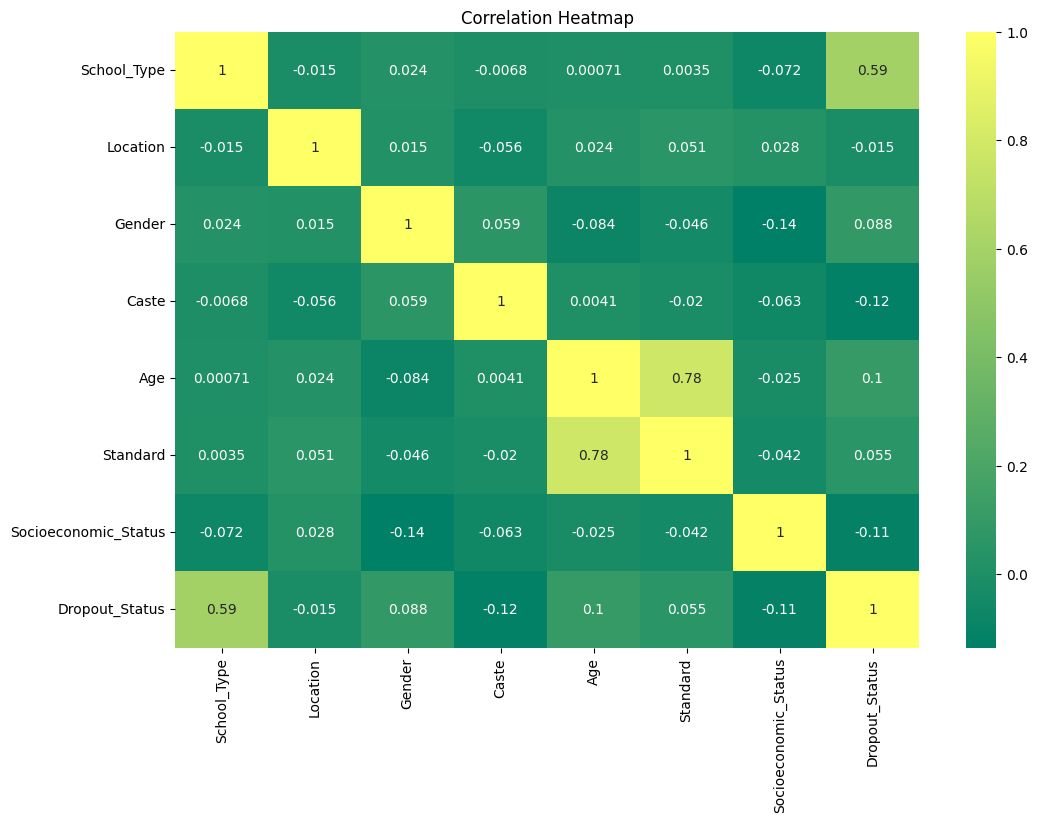

In [ ]:
from sklearn.preprocessing import LabelEncoder
# df_corr = df.copy()

le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='summer')
plt.title("Correlation Heatmap")
plt.show()


graphical representation

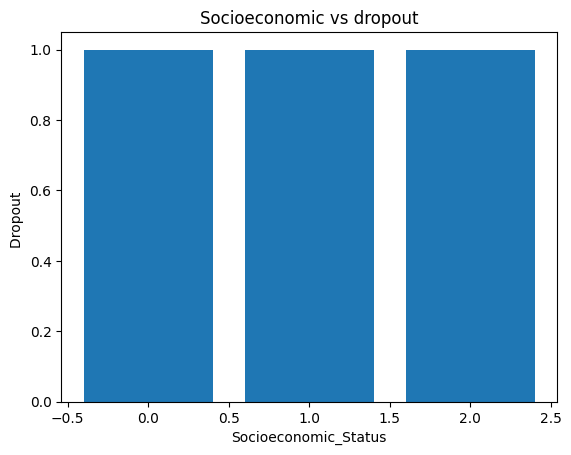

In [ ]:

plt.bar(df['Socioeconomic_Status'], df['Dropout_Status'])
plt.title("Socioeconomic vs dropout")
plt.xlabel("Socioeconomic_Status")
plt.ylabel("Dropout ")
plt.show()


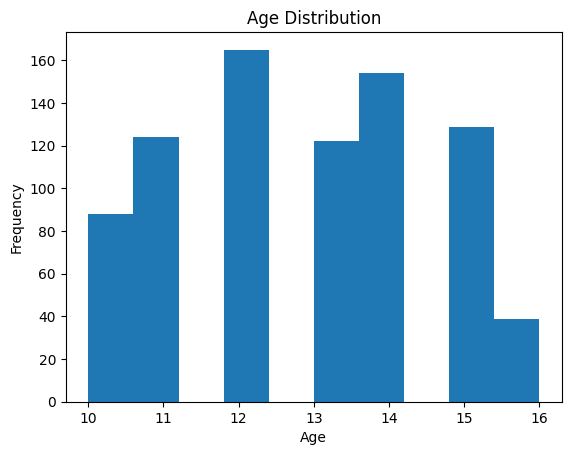

In [ ]:

plt.hist(df['Age'], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


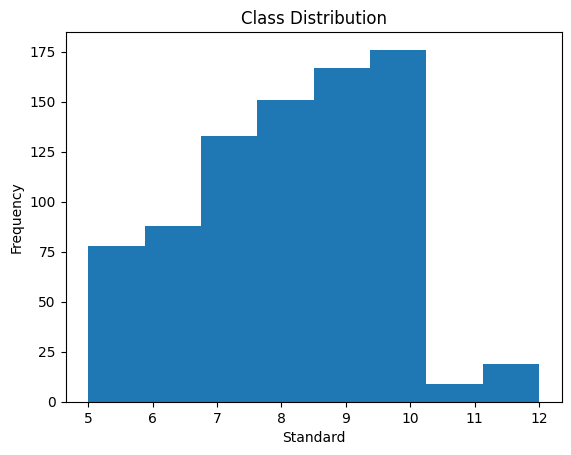

In [ ]:
plt.hist(df['Standard'], bins=8)
plt.title("Class Distribution")
plt.xlabel("Standard")
plt.ylabel("Frequency")
plt.show()


In [ ]:
df

,School_Type,Location,Gender,Caste,Age,Standard,Socioeconomic_Status,Dropout_Status
0,0,1,1,2,14,8,1,0
1,1,0,0,0,15,7,0,1
2,0,0,1,3,13,9,2,0
3,1,1,0,1,12,10,0,1
4,0,0,1,2,16,8,1,0
...,...,...,...,...,...,...,...,...
10101,0,0,0,3,15,10,2,1
10149,0,0,1,2,15,10,0,1
10155,0,1,1,0,12,10,0,1
10156,1,0,0,3,11,9,1,0


from matplotlib import pyplot as plt
df['School_Type'].plot(kind='hist', bins=20, title='School_Type')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['Location'].plot(kind='hist', bins=20, title='Location')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['Gender'].plot(kind='hist', bins=20, title='Gender')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['Caste'].plot(kind='hist', bins=20, title='Caste')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
df.plot(kind='scatter', x='Caste', y='Age', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['School_Type'].plot(kind='line', figsize=(8, 4), title='School_Type')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df['Location'].plot(kind='line', figsize=(8, 4), title='Location')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df['Gender'].plot(kind='line', figsize=(8, 4), title='Gender')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df['Caste'].plot(kind='line', figsize=(8, 4), title='Caste')
plt.gca().spines[['top', 'right']].set_visible(False)

TRaining the data ***Logistic regression***

X_train: (656, 7)
X_test: (165, 7)
y_train: (656,)
y_test: (165,)
Accuracy: 0.8424242424242424
Precision Score: 0.8554216867469879
Recall Score: 0.8352941176470589
F1 Score: 0.8452380952380952
R**2 Score: 0.36911764705882366


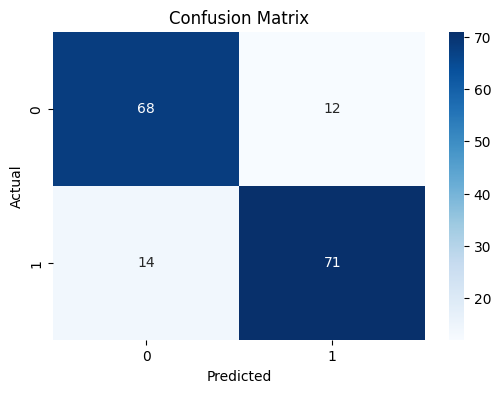

              precision    recall  f1-score   support

           0       0.83      0.85      0.84        80
           1       0.86      0.84      0.85        85

    accuracy                           0.84       165
   macro avg       0.84      0.84      0.84       165
weighted avg       0.84      0.84      0.84       165

ROC-AUC Score: 0.8883823529411764


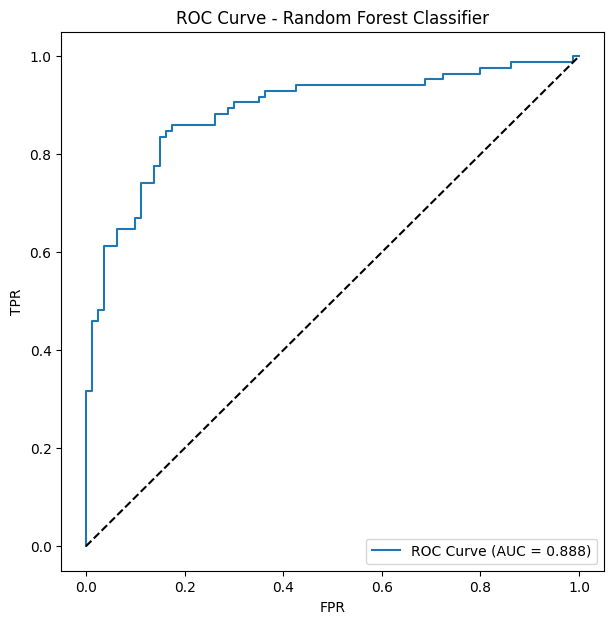

In [ ]:
from sklearn.preprocessing import StandardScaler
standard_scale=StandardScaler()
x = df.drop(columns=['Dropout_Status'])
y = df['Dropout_Status']
# from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=43
)

print("X_train:", x_train.shape)
print("X_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


model = LogisticRegression(max_iter=100000)
x_train = standard_scale.fit_transform(x_train)
x_test = standard_scale.transform(x_test)
model.fit(x_train, y_train)


y_pred = model.predict(x_test)

print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision Score:",precision_score(y_test,y_pred))
print("Recall Score:",recall_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
print("R**2 Score:",r2_score(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred))

y_prob = model.predict_proba(x_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Random Forest Classifier")
plt.legend(loc="lower right")
plt.show()







RANDOM FOREST **bold text**


X_train: (656, 7)
X_test: (165, 7)
y_train: (656,)
y_test: (165,)
Accuracy: 0.9696969696969697
Precision Score: 1.0
Recall Score: 0.9411764705882353
F1 Score: 0.9696969696969697
R**2 Score: 0.8786764705882353


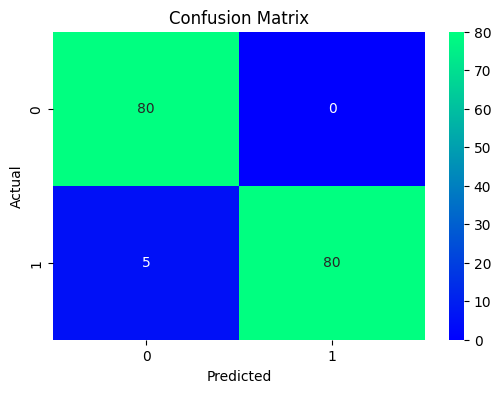

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        80
           1       1.00      0.94      0.97        85

    accuracy                           0.97       165
   macro avg       0.97      0.97      0.97       165
weighted avg       0.97      0.97      0.97       165

ROC-AUC Score: 0.9941176470588236


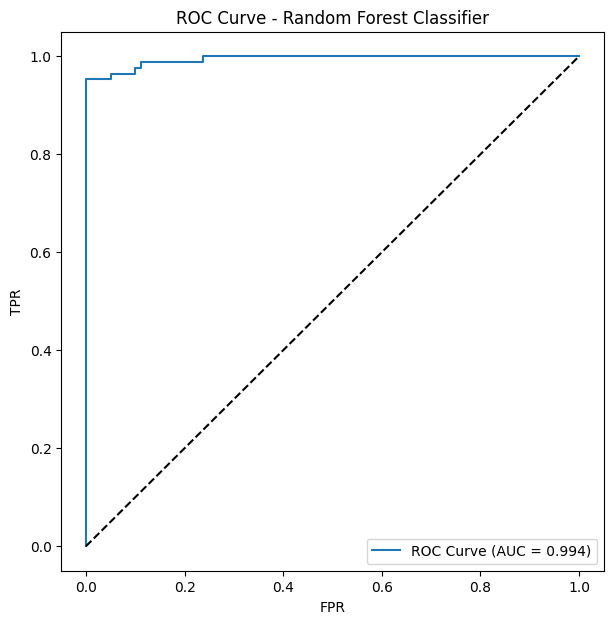

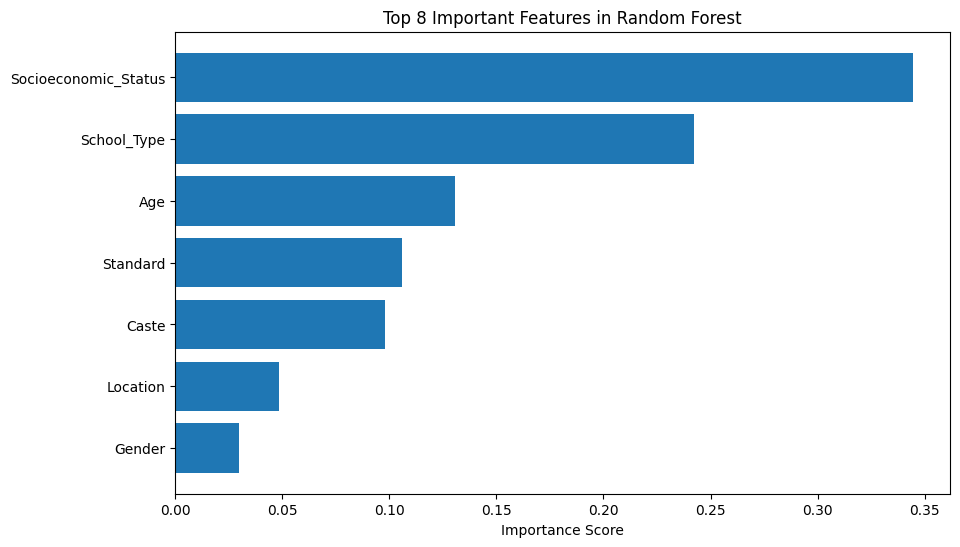

Optimal threshold  0.49360846560846566


In [ ]:
from sklearn.preprocessing import StandardScaler
standard_scale=StandardScaler()
x = df.drop(columns=['Dropout_Status'])
y = df['Dropout_Status']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=43
)
x_train = standard_scale.fit_transform(x_train)
x_test = standard_scale.transform(x_test)

print("X_train:", x_train.shape)
print("X_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

model1=RandomForestClassifier(
    n_estimators=450,
    random_state=42)

model1.fit(x_train, y_train)
y_pred = model1.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision Score:",precision_score(y_test,y_pred))
print("Recall Score:",recall_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
print("R**2 Score:",r2_score(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='winter')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred))

y_prob = model1.predict_proba(x_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Random Forest Classifier")
plt.legend(loc="lower right")
plt.show()

feature_importance = model1.feature_importances_
indices = np.argsort(feature_importance)[-8:]  # top  8features

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), feature_importance[indices], align='center')
plt.yticks(range(len(indices)), [x.columns[i] for i in indices])
plt.xlabel('Importance Score')
plt.title('Top 8 Important Features in Random Forest')
plt.show()

best_threshold=thresholds[(tpr-fpr).argmax()] #optimal soln
print("Optimal threshold ", best_threshold)



**Navies Bayes**

Accuracy: 0.793939393939394
Precision: 0.7294117647058823
Recall: 0.8493150684931506
F1 Score: 0.7848101265822784
ROC-AUC: 0.9107355568790947
R**2 Score: 0.16468135795116168


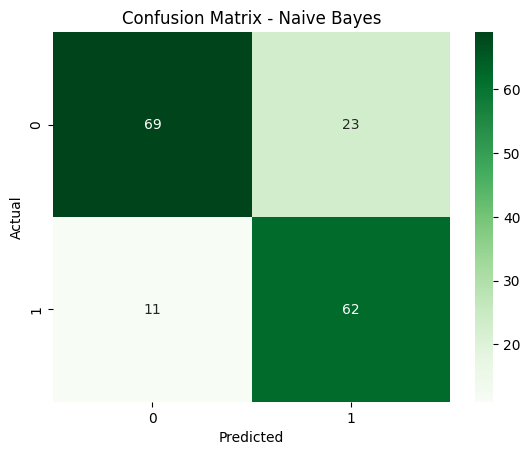


Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.75      0.80        92
           1       0.73      0.85      0.78        73

    accuracy                           0.79       165
   macro avg       0.80      0.80      0.79       165
weighted avg       0.80      0.79      0.79       165



In [ ]:

from sklearn.naive_bayes import GaussianNB

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=43, stratify=y
)

model_nb = GaussianNB()
model_nb.fit(x_train, y_train)

y_pred = model_nb.predict(x_test)
y_prob = model_nb.predict_proba(x_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("R**2 Score:",r2_score(y_test,y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


***Decision Tree***

X_train: (656, 7)
X_test: (165, 7)
y_train: (656,)
y_test: (165,)
Accuracy: 0.8181818181818182
Precision Score: 0.8160919540229885
Recall Score: 0.8352941176470589
F1 Score: 0.8255813953488372


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


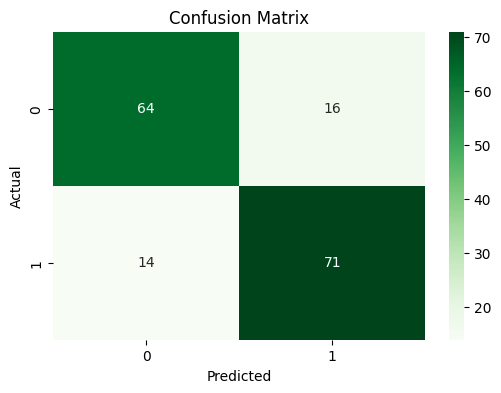

              precision    recall  f1-score   support

           0       0.82      0.80      0.81        80
           1       0.82      0.84      0.83        85

    accuracy                           0.82       165
   macro avg       0.82      0.82      0.82       165
weighted avg       0.82      0.82      0.82       165

ROC-AUC Score: 0.8176470588235295


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


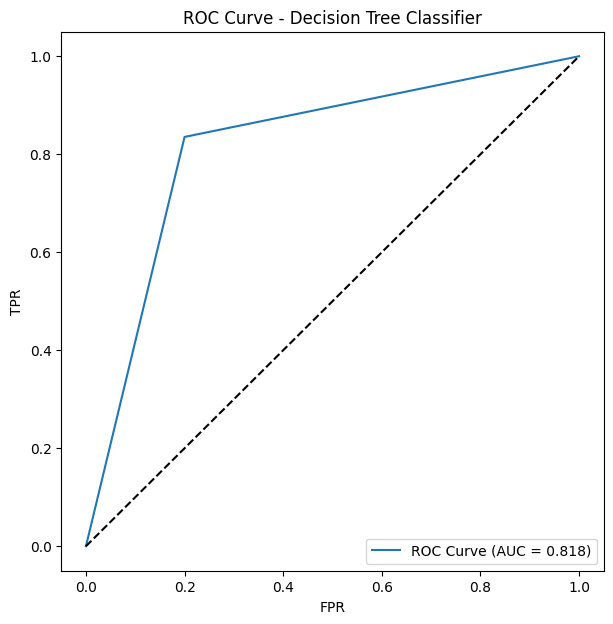

Optimal threshold  1.0


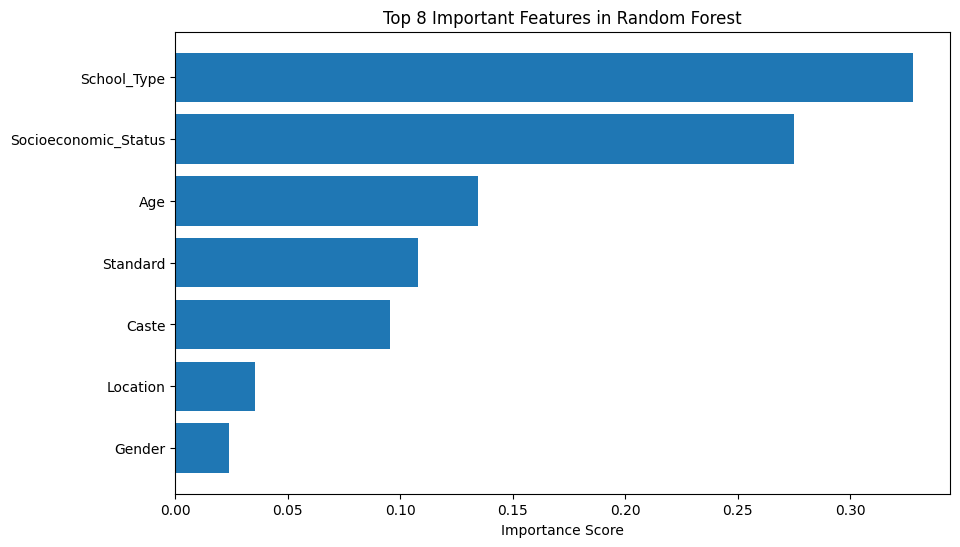

In [ ]:
from sklearn.preprocessing import StandardScaler
standard_scale=StandardScaler()
x = df.drop(columns=['Dropout_Status'])
y = df['Dropout_Status']
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=43
)

print("X_train:", x_train.shape)
print("X_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train = standard_scale.fit_transform(x_train)
model1=DecisionTreeClassifier(
    criterion='gini',
    random_state=43
)

model1.fit(x_train, y_train)
y_pred = model1.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision Score:",precision_score(y_test,y_pred))
print("Recall Score:",recall_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
# print("R**2 Score:",r2_score(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred))

y_prob = model1.predict_proba(x_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Decision Tree Classifier")
plt.legend(loc="lower right")
plt.show()



# #
best_threshold=thresholds[(tpr-fpr).argmax()] #optimal soln
print("Optimal threshold ", best_threshold)

feature_importance = model1.feature_importances_
indices = np.argsort(feature_importance)[-8:]  # top 10 features

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), feature_importance[indices], align='center')
plt.yticks(range(len(indices)), [x.columns[i] for i in indices])
plt.xlabel('Importance Score')
plt.title('Top 8 Important Features in Random Forest')
plt.show()

**Copmaring all the models**

In [ ]:
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# def get_metrics(model_name, y_test, y_pred, y_prob):
#     return {
#         "Model": model_name,
#         "Accuracy": accuracy_score(y_test, y_pred),
#         "Precision": precision_score(y_test, y_pred),
#         "Recall": recall_score(y_test, y_pred),
#         "F1 Score": f1_score(y_test, y_pred),
#         "ROC-AUC": roc_auc_score(y_test, y_prob)
#     }
# results = []

# # # 1. Logistic Regression
# model = LogisticRegression(max_iter=10000)
# # x_train = standard_scale.fit_transform(x_train)
# # x_test = standard_scale.transform(x_test)
# model.fit(x_train, y_train)


# y_pred = model.predict(x_test)
# y_prob = model.predict_proba(x_test)[:,1]
# results.append(get_metrics("Logistic Regression", y_test, y_pred, y_prob))

# # # 2. Random Forest
# model1=RandomForestClassifier(
#     n_estimators=300,
#     random_state=42)

# model1.fit(x_train, y_train)
# y_pred = model1.predict(x_test)
# y_prob = model1.predict_proba(x_test)[:,1]
# results.append(get_metrics("Random Forest", y_test, y_pred, y_prob))

# # # 3. Naive Bayes

# model_nb = GaussianNB()
# model_nb.fit(x_train, y_train)

# y_pred = model_nb.predict(x_test)
# y_prob = model_nb.predict_proba(x_test)[:, 1]

# results.append(get_metrics("Naive Bayes", y_test, y_pred, y_prob))

# print(results)


bagging and boosting

In [ ]:
# from sklearn.ensemble import BaggingClassifier,VotingClassifier
